In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil
import copy

In [2]:
# Script to standardize images in a dataset by padding and resizing

# Define the paths
original_dataset_path = '../datasets'
transformed_dataset_path = '../datasets/standardized'

# Create the new directory structure
os.makedirs(transformed_dataset_path, exist_ok=True)
categories = ['marchandise', 'administration', 'passager_gros', 'passager_petit', 'restaurant']
for category in categories:
    os.makedirs(os.path.join(transformed_dataset_path, category), exist_ok=True)

# Iterate through each category and image in the original dataset
for category in categories:
    original_category_path = os.path.join(original_dataset_path, category)
    transformed_category_path = os.path.join(transformed_dataset_path, category)

    for filename in os.listdir(original_category_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            # Load the original image
            original_image_path = os.path.join(original_category_path, filename)
            original_image = Image.open(original_image_path)

            # Calculate the padding
            width, height = original_image.size
            if width > height:
                padding = (width - height) // 2
                pad_transform = transforms.Pad((0, padding, 0, padding), fill=0)  # Pad the top and bottom
            else:
                padding = (height - width) // 2
                pad_transform = transforms.Pad((padding, 0, padding, 0), fill=0)  # Pad the left and right

            # Define the transformation pipeline
            transform = transforms.Compose([
                pad_transform,  # Pad the image to make it square
                transforms.Resize(256)  # Resize the padded image to 256x256 pixels
            ])

            # Apply the transformation pipeline to the image
            transformed_image = transform(original_image)

            # Save the transformed image
            transformed_image_path = os.path.join(transformed_category_path, filename)
            transformed_image.save(transformed_image_path)

In [3]:
# Data augmentation pipeline

data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),            # sens du bateau
    transforms.RandomRotation(degrees=5),              # rotation très légère, inclinaison caméra...
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),  # crop léger + zoom

    # differents réglages de luminosité, contraste, saturation et teinte
    transforms.ColorJitter(
        brightness=0.3, 
        contrast=0.3, 
        saturation=0.3, 
        hue=0.05
    ),

    # normalization pour ResNet
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
standardized_dataset_path = '../datasets/standardized'
standardized_augmented_dataset_path = '../datasets/standardized_augmented'

# Target images par classe
target_per_class = 600

# Crée le répertoire final
os.makedirs(standardized_augmented_dataset_path, exist_ok=True)

# Parcours des catégories
for category in os.listdir(standardized_dataset_path):
    category_path = os.path.join(standardized_dataset_path, category)
    if not os.path.isdir(category_path):
        continue

    # Parcours des fichiers png pour les convertir en jpg
    for filename in os.listdir(category_path):
        if filename.lower().endswith('.png'):
            png_path = os.path.join(category_path, filename)
            # Charge l'image
            img = Image.open(png_path).convert('RGB')
            # Nouveau nom avec .jpg
            jpg_filename = os.path.splitext(filename)[0] + '.jpg'
            jpg_path = os.path.join(category_path, jpg_filename)
            # Sauvegarde en jpg
            img.save(jpg_path, 'JPEG', quality=95)
            # Supprime le fichier png original
            os.remove(png_path)

    # Création du dossier pour la catégorie augmentée
    augmented_category_path = os.path.join(standardized_augmented_dataset_path, category)
    os.makedirs(augmented_category_path, exist_ok=True)

    # Liste des images originales
    original_images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg'))]
    num_original = len(original_images)
    if num_original == 0:
        continue

    # Calcul du nombre d'augmentations par image
    num_augmented_images = max(0, int((target_per_class / num_original) - 1))
    print(f'Category: {category}, original: {num_original}, augment per image: {num_augmented_images}')

    # Boucle sur chaque image
    for filename in original_images:
        original_image_path = os.path.join(category_path, filename)
        original_image = Image.open(original_image_path).convert("RGB")

        # Copie de l'image originale
        shutil.copy(original_image_path, os.path.join(augmented_category_path, filename))

        # Génération des images augmentées
        for i in range(num_augmented_images):
            # Applique la pipeline d'augmentation existante
            augmented_tensor = data_augmentation(original_image)
            
            # Convertit le Tensor normalisé en PIL pour sauvegarder
            # On remet les valeurs entre 0 et 1 avant conversion
            unnorm = transforms.Normalize(
                mean=[-m/s for m, s in zip([0.485,0.456,0.406],[0.229,0.224,0.225])],
                std=[1/s for s in [0.229,0.224,0.225]]
            )
            augmented_image = unnorm(augmented_tensor).clamp(0,1)
            augmented_image_pil = transforms.ToPILImage()(augmented_image)

            augmented_image_path = os.path.join(augmented_category_path, f'augmented_{i}_{filename}')
            augmented_image_pil.save(augmented_image_path)

Category: administration, original: 73, augment per image: 7
Category: marchandise, original: 237, augment per image: 1
Category: passager_gros, original: 211, augment per image: 1
Category: passager_petit, original: 133, augment per image: 3
Category: restaurant, original: 118, augment per image: 4


In [6]:
# Define the paths to the training and testing datasets
train_dataset_path = '../datasets/train'
test_dataset_path = '../datasets/test'

# Split the dataset into training and testing sets
os.makedirs(train_dataset_path, exist_ok=True)
os.makedirs(test_dataset_path, exist_ok=True)

for category in os.listdir(standardized_augmented_dataset_path):
    category_path = os.path.join(standardized_augmented_dataset_path, category)
    if os.path.isdir(category_path):
        train_category_path = os.path.join(train_dataset_path, category)
        test_category_path = os.path.join(test_dataset_path, category)
        os.makedirs(train_category_path, exist_ok=True)
        os.makedirs(test_category_path, exist_ok=True)

        for filename in os.listdir(category_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                image_path = os.path.join(category_path, filename)
                if np.random.random() < 0.8:  # 80% of the images will be used for training
                    shutil.copy(image_path, os.path.join(train_category_path, filename))
                else:  # 20% of the images will be used for testing
                    shutil.copy(image_path, os.path.join(test_category_path, filename))

In [11]:
# Verify and correct the image formats in the training and testing datasets

# Define the target dimensions for the images
target_size = (256, 256)

# Define the resize transformation
resize_transform = transforms.Resize(target_size)

# Function to resize images in a dataset
def resize_images(dataset_path):
    # Iterate through each category and image in the dataset
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            for filename in os.listdir(category_path):
                if filename.endswith(('.jpg', '.jpeg', '.png')):
                    # Load the image
                    image_path = os.path.join(category_path, filename)
                    image = Image.open(image_path)

                    # Resize the image
                    resized_image = resize_transform(image)

                    # Save the resized image
                    resized_image.save(image_path)

# Resize images in the train and test datasets
resize_images(train_dataset_path)
resize_images(test_dataset_path)

In [12]:
# Load the training and testing datasets
train_dataset = ImageFolder(train_dataset_path, transform=transforms.ToTensor())
test_dataset = ImageFolder(test_dataset_path, transform=transforms.ToTensor())

# Create the data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
## Not used

# Calculate class weights to handle class imbalance
from collections import Counter

# Initialize a counter to count the occurrences of each class
class_counts = Counter()

# Iterate through the train_loader to count the occurrences of each class
for _, labels in train_loader:
    class_counts.update(labels.tolist())

# Calculate the class weights
num_classes = len(class_counts)
class_weights = {class_idx: 1.0 / class_counts[class_idx] for class_idx in class_counts}

# Convert the class weights to a tensor
class_weights_tensor = torch.tensor([class_weights[class_idx] for class_idx in range(num_classes)], dtype=torch.float32)

In [13]:
from torchvision.models import ResNet18_Weights

# -----------------------------
# Load pretrained ResNet18
# -----------------------------
weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# -----------------------------
# Freeze everything
# -----------------------------
for param in model.parameters():
    param.requires_grad = False

# -----------------------------
# Unfreeze high-level layers (3 and 4)
# -----------------------------
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# -----------------------------
# Replace classification head
# -----------------------------
num_features = model.fc.in_features
num_classes = len(categories)  # ['marchandise', 'administration', 'passager_gros', 'passager_petit', 'restaurant']

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(256, num_classes)
)

# Unfreeze head
for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
num_epochs = 100
lr = 0.001

criterion = nn.CrossEntropyLoss()  ## Not using class weights : weight=class_weights_tensor
optimizer = optim.Adam(model.fc.parameters(), lr=lr)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader if phase == 'train' else test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))
        epoch_acc = running_corrects.double() / (len(train_loader.dataset) if phase == 'train' else len(test_loader.dataset))

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_loss_history.append(epoch_loss)
            train_acc_history.append(epoch_acc)
        else:
            val_loss_history.append(epoch_loss)
            val_acc_history.append(epoch_acc)

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
torch.save(best_model_wts, '../models/boat_recognition_model.pth')

Epoch 0/99
----------
train Loss: 1.3832 Acc: 0.5491
val Loss: 0.9512 Acc: 0.7230
Epoch 1/99
----------
train Loss: 0.9502 Acc: 0.7404
val Loss: 0.8153 Acc: 0.7419
Epoch 2/99
----------
train Loss: 0.8035 Acc: 0.7754
val Loss: 0.6635 Acc: 0.7975
Epoch 3/99
----------
train Loss: 0.7348 Acc: 0.7917
val Loss: 0.6794 Acc: 0.7774
Epoch 4/99
----------
train Loss: 0.6776 Acc: 0.7980
val Loss: 0.6027 Acc: 0.8046
Epoch 5/99
----------
train Loss: 0.6053 Acc: 0.8218
val Loss: 0.5399 Acc: 0.8278
Epoch 6/99
----------
train Loss: 0.5864 Acc: 0.8315
val Loss: 0.5457 Acc: 0.8203
Epoch 7/99
----------
train Loss: 0.5515 Acc: 0.8373
val Loss: 0.5457 Acc: 0.8168
Epoch 8/99
----------
train Loss: 0.5439 Acc: 0.8311
val Loss: 0.4933 Acc: 0.8401
Epoch 9/99
----------
train Loss: 0.5120 Acc: 0.8468
val Loss: 0.4933 Acc: 0.8339
Epoch 10/99
----------
train Loss: 0.4951 Acc: 0.8442
val Loss: 0.4545 Acc: 0.8475
Epoch 11/99
----------
train Loss: 0.4772 Acc: 0.8508
val Loss: 0.5428 Acc: 0.8072
Epoch 12/99
--

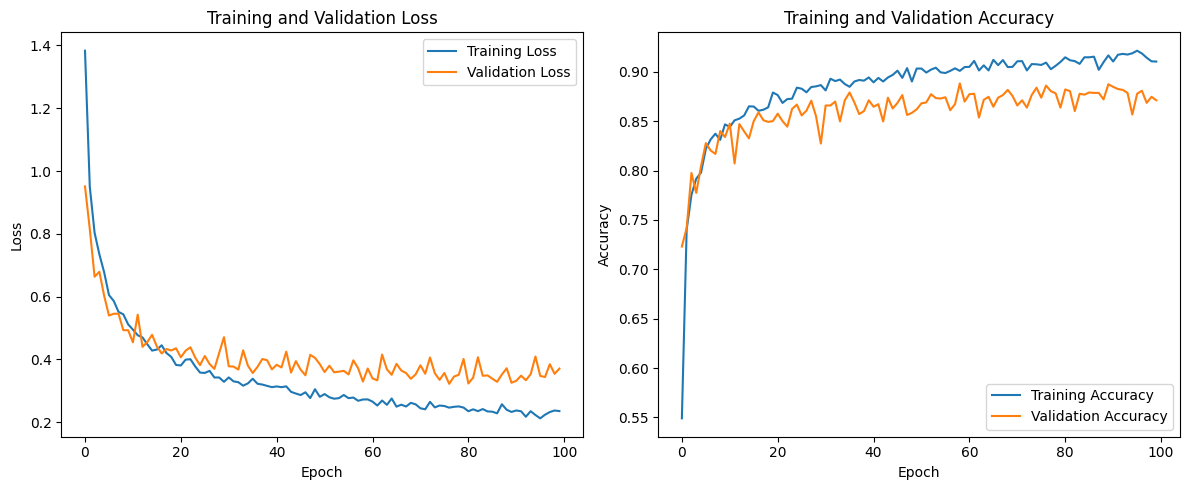

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Class names: {0: 'administration', 1: 'marchandise', 2: 'passager_gros', 3: 'passager_petit', 4: 'plaisance', 5: 'restaurant'}


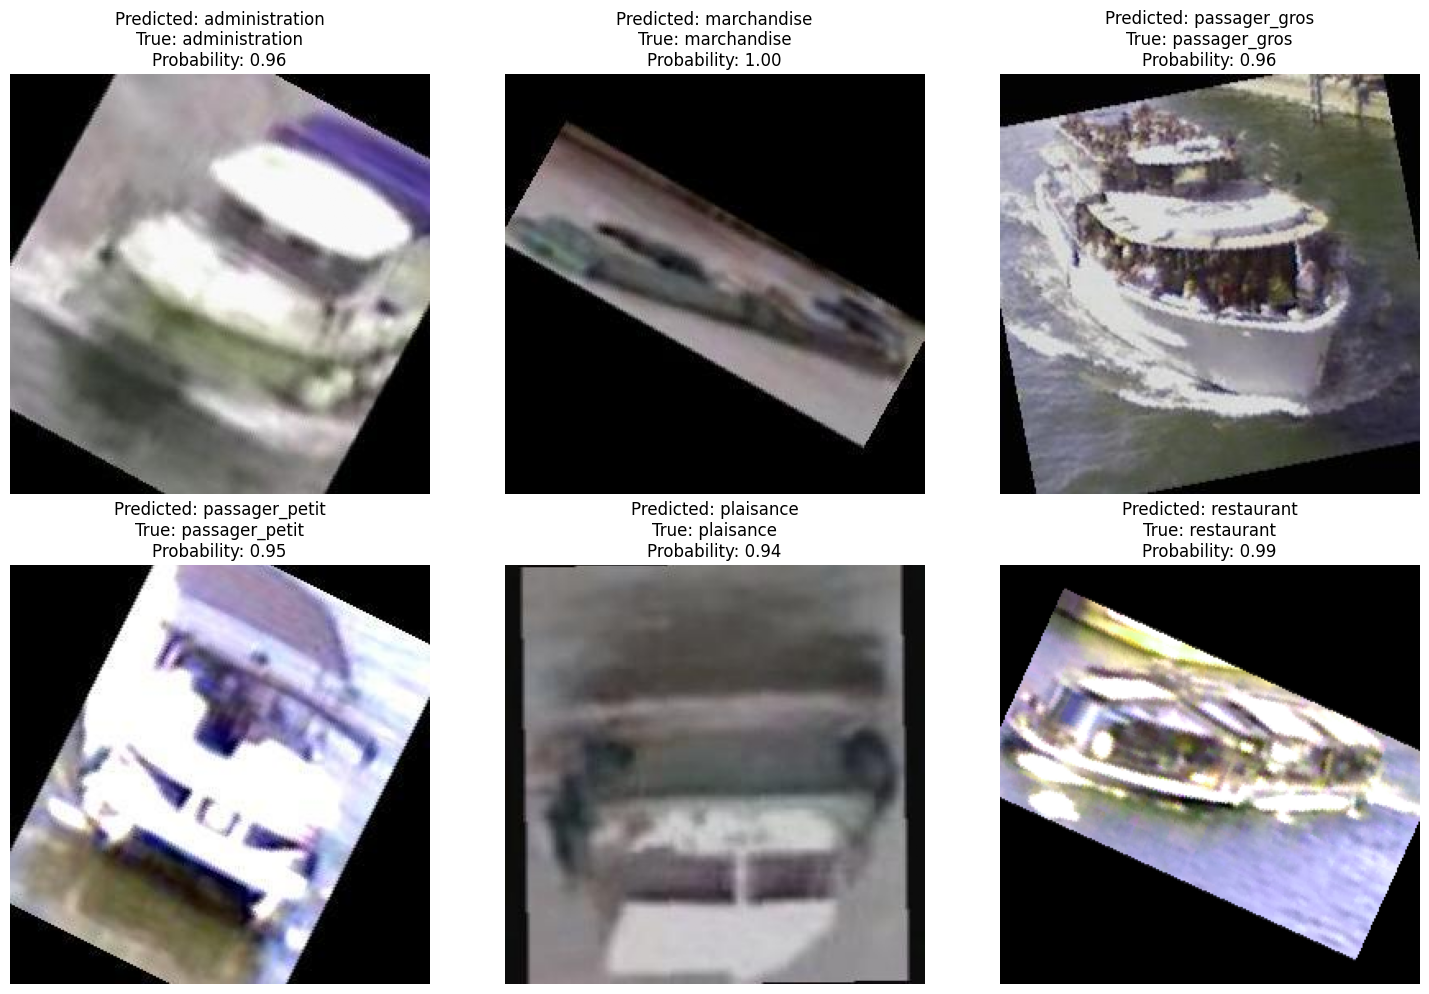

In [ ]:
from collections import defaultdict

# Load the pre-trained model weights
model_weights = torch.load('../models/boat_recognition_model.pth')

# Initialize a ResNet18 model without pre-trained weights
model = models.resnet18(weights=None)
num_classes = 5  # ['marchandise', 'administration', 'passager_gros', 'passager_petit', 'restaurant']

# Modify the head
num_features = model.fc.in_features 
model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes)
    )

# Load the model weights into the model
model.load_state_dict(model_weights, strict=True)
model.eval()

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Create a dataset and data loader for testing
test_dataset = ImageFolder(test_dataset_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32)

# Get class names and create a dictionary mapping class indices to names
class_names_dict = {i: name for i, name in enumerate(test_dataset.classes)}
print(f'Class names: {class_names_dict}')

# Store images by their class labels
images_by_class = defaultdict(list)

# Iterate through the test dataset and store images in the dictionary
for images, labels in test_loader:
    for img, label in zip(images, labels):
        class_idx = label.item()
        images_by_class[class_idx].append(img)

# Ensure all classes are represented in the dictionary
assert len(images_by_class) == num_classes

# Create a figure to display sample images with predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Display one random image per class with prediction information
for i, class_idx in enumerate(images_by_class.keys()):
    random_idx = np.random.randint(0, len(images_by_class[class_idx]))
    img = images_by_class[class_idx][random_idx]

    # Make a prediction for the image
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1)
        predicted_probability = probabilities[0][predicted_class].item()

    # Get the predicted and true class names
    predicted_class_name = class_names_dict[predicted_class.item()]
    true_class_name = class_names_dict[class_idx]

    # Display the image with prediction information
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f'Predicted: {predicted_class_name}\nTrue: {true_class_name}\nProbability: {predicted_probability:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

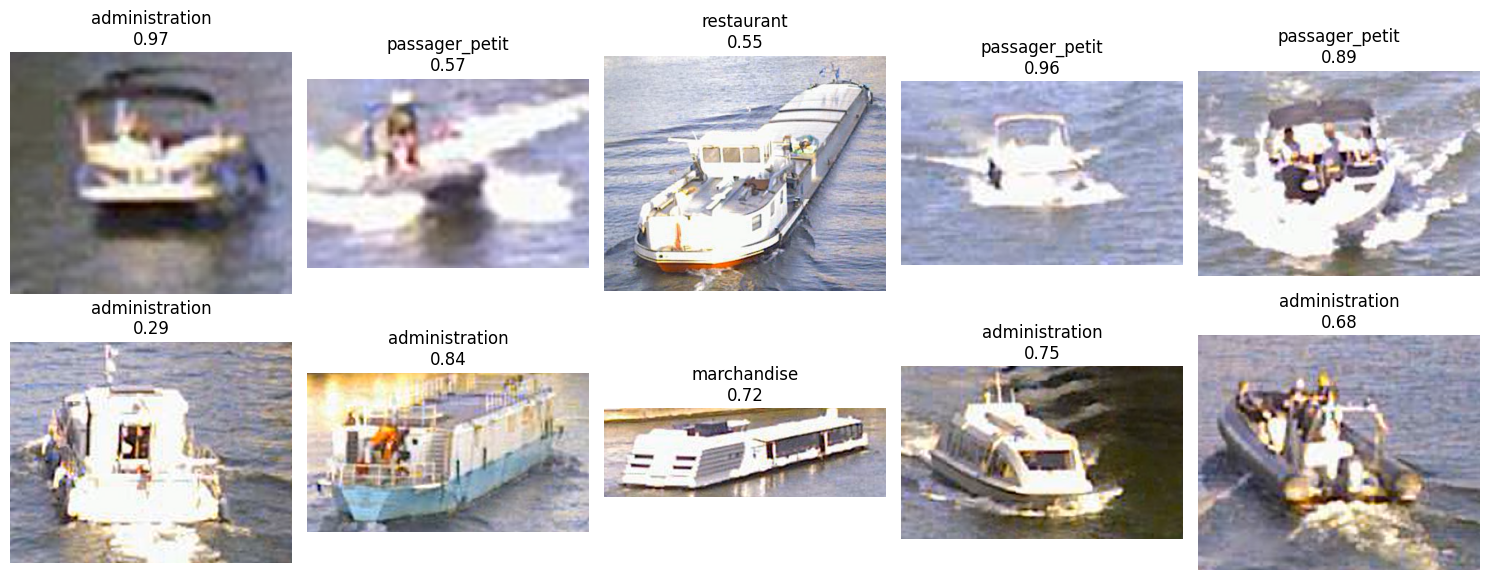

In [25]:
import random
import torch.nn.functional as F

num_classes = 5
class_names = [
    'administration',
    'marchandise',
    'passager_gros',
    'passager_petit',
    'restaurant'
]

model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

state_dict = torch.load('../models/boat_recognition_model_20epochs.pth')
model.load_state_dict(state_dict)
model.eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Pad(10, fill=0),
    transforms.ToTensor(),
])

validation_path = '../datasets/validation'

image_files = [
    f for f in os.listdir(validation_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

selected_images = random.sample(image_files, 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(validation_path, img_name)

    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    pred_class = class_names[pred_idx]

    axes[i].imshow(img)
    axes[i].set_title(f"{pred_class}\n{pred_prob:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()